
# Triadic Cell Notebook v2
## Hard-coupled B / T / R

This version fixes the main problem in v1:

the three legs are **not** treated as independent knobs anymore.

The new rule is:

- **Binding (B)** must retain enough structure for change to matter
- **Transformation (T)** must generate real delta
- **Readout (R)** is only allowed to expose **bound transformed difference**
- **Memory** can only grow from **held + changed + legible** state

So the machine is no longer:

\[
B + T + R
\]

It is closer to:

\[
B \otimes T \otimes R
\]

That means only the full triad should sustain:
- coherence
- becoming
- readable output
- retained memory



## Hardware translation

Use the machine picture:

- **B** = register / latch / held charge / retained state
- **T** = ALU update / transition law / lawful change
- **R** = bus / exposed residue / observable output

The failure modes should now look like this:

- **BTR** = real machine
- **BT only** = hidden internal machine, little outward legibility
- **BR only** = visible shell, mostly frozen
- **TR only** = flicker / flux / weak identity retention


In [1]:

from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

print("Environment ready.")


Environment ready.



## State definition

We track four things:

- `coherence`: does the machine still hold together?
- `state`: internal configuration
- `readout`: exposed observable signal
- `memory`: retained readable difference

The key difference from v1:

**memory no longer grows just because something changed or because something was visible.**

It grows only when the system is:
- bound enough to preserve a change
- transformed enough to generate a real delta
- readable enough for that delta to be externally legible


In [2]:

@dataclass
class TriadicState:
    coherence: float = 0.75
    state: float = 0.20
    readout: float = 0.00
    memory: float = 0.00



## Hard-coupled triadic cell

Design principles in this cell:

1. **Transformation costs coherence** if binding is weak.
2. **Readout depends on delta**, not just on raw state.
3. **Memory depends on the full triad** and decays if binding is weak.
4. **Readout shell without change** dies down.
5. **Flicker without binding** cannot accumulate durable memory.

This is intentionally more sequential-machine-like and less soft/additive.


In [3]:

class TriadicCellV2:
    def __init__(self, B: float, T: float, R: float):
        self.B = float(B)
        self.T = float(T)
        self.R = float(R)

    @staticmethod
    def _clip(x: float) -> float:
        return float(np.clip(x, 0.0, 1.0))

    def step(self, s: TriadicState, drive: float) -> Tuple[TriadicState, float]:
        # --- Binding / coherence ---
        # Binding replenishes durability; transformation consumes it if unsupported.
        coherence_gain = 0.08 * self.B * (1.0 - s.coherence)
        coherence_cost = 0.14 * self.T * (1.0 - self.B) + 0.04 * abs(s.readout - s.state)
        coherence_leak = 0.02 * (1.0 - self.B)
        coherence = s.coherence + coherence_gain - coherence_cost - coherence_leak
        coherence = self._clip(coherence)

        # --- Transformation / internal update ---
        # State moves only when both binding and transformation can cooperate.
        # Without B, T mostly creates unstable motion that cannot settle.
        stable_drive = self.B * self.T * (0.15 + 0.70 * drive)
        unstable_penalty = 0.10 * self.T * (1.0 - self.B)
        relaxation = 0.05 * (s.state - 0.5)  # prevents instant rail saturation
        state = s.state + stable_drive - unstable_penalty - relaxation
        state = self._clip(state)

        delta_state = abs(state - s.state)

        # --- Readout / emitted residue ---
        # Readout is not allowed to be "healthy" without transformed difference.
        # BR becomes visible shell only; TR flickers but cannot stabilize.
        readable_delta = self.B * self.T * self.R * delta_state
        shell_decay = 0.60 * s.readout * (1.0 - delta_state)
        readout = s.readout + 1.60 * readable_delta - shell_decay
        readout = self._clip(readout)

        # --- Memory / retained readable difference ---
        # Memory only grows from bound + changed + legible state.
        # Weak B causes memory bleed.
        memory_gain = 2.40 * self.B * self.T * self.R * delta_state * coherence
        memory_bleed = (0.10 + 0.35 * (1.0 - self.B)) * s.memory
        memory = s.memory + memory_gain - memory_bleed
        memory = self._clip(memory)

        next_state = TriadicState(
            coherence=coherence,
            state=state,
            readout=readout,
            memory=memory,
        )
        emitted = readout
        return next_state, emitted



## Drive signal

We use a changing input pressure so the cell has something to respond to.

Think of it as:
- clocked disturbance
- inbound data pressure
- environmental variance


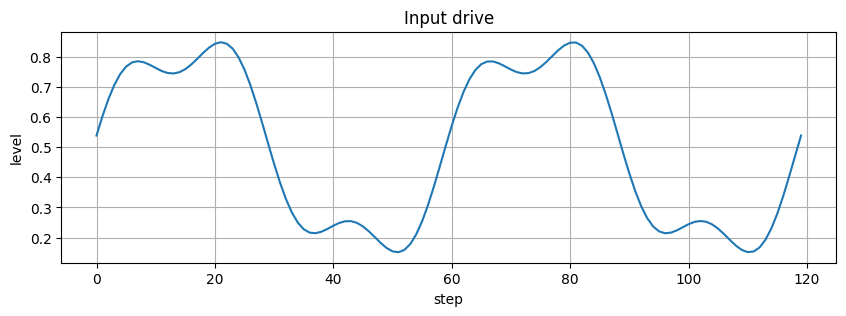

In [4]:

def make_drive(steps: int = 120) -> np.ndarray:
    t = np.linspace(0, 4 * np.pi, steps)
    slow = 0.5 + 0.35 * np.sin(t)
    fast = 0.10 * np.sin(3 * t + 0.4)
    drive = slow + fast
    return np.clip(drive, 0.0, 1.0)

drive = make_drive()

plt.figure(figsize=(10, 3))
plt.plot(drive)
plt.title("Input drive")
plt.xlabel("step")
plt.ylabel("level")
plt.show()



## Run the four structural cases


In [5]:

def run_case(name: str, B: float, T: float, R: float, steps: int = 120) -> pd.DataFrame:
    cell = TriadicCellV2(B, T, R)
    s = TriadicState()
    rows: List[Dict[str, float]] = []

    for i, x in enumerate(make_drive(steps)):
        s, emitted = cell.step(s, float(x))
        rows.append({
            "step": i,
            "case": name,
            "B": B,
            "T": T,
            "R": R,
            "coherence": s.coherence,
            "state": s.state,
            "readout": s.readout,
            "memory": s.memory,
            "emitted": emitted,
        })

    return pd.DataFrame(rows)

cases = {
    "BTR": (1.0, 1.0, 1.0),
    "BT only": (1.0, 1.0, 0.0),
    "BR only": (1.0, 0.0, 1.0),
    "TR only": (0.0, 1.0, 1.0),
}

results = {name: run_case(name, *vals) for name, vals in cases.items()}

pd.concat(results.values(), ignore_index=True).head()


,step,case,B,T,R,coherence,state,readout,memory,emitted
0,0,BTR,1.0,1.0,1.0,0.762000,0.742259,0.867615,0.991684,0.867615
1,1,BTR,1.0,1.0,1.0,0.776026,1.000000,0.893603,1.000000,0.893603
2,2,BTR,1.0,1.0,1.0,0.789688,1.000000,0.357441,0.900000,0.357441
3,3,BTR,1.0,1.0,1.0,0.780810,1.000000,0.142976,0.810000,0.142976
4,4,BTR,1.0,1.0,1.0,0.764065,1.000000,0.057191,0.729000,0.057191


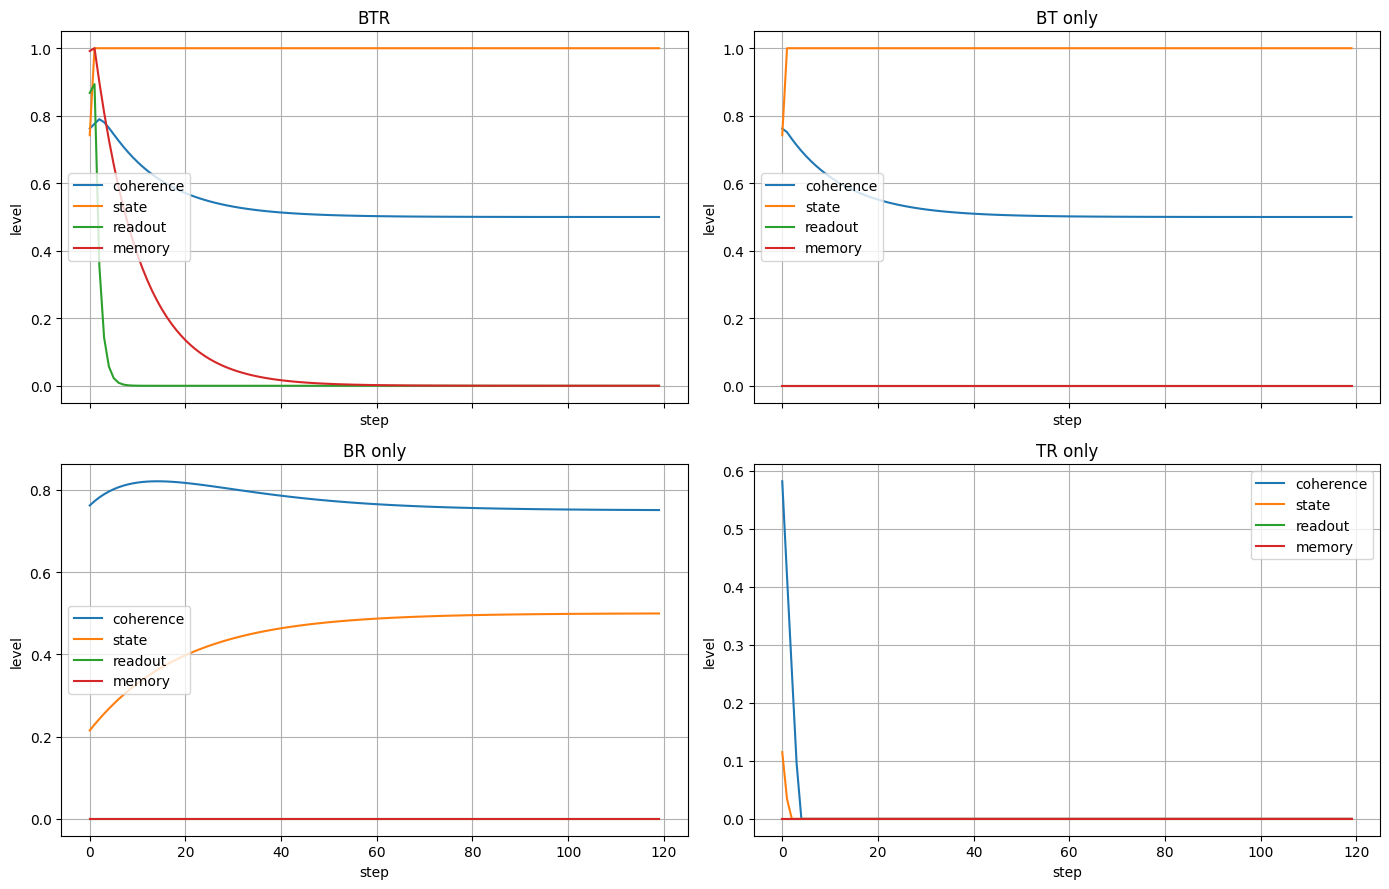

In [6]:

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
axes = axes.ravel()

for ax, (name, df) in zip(axes, results.items()):
    ax.plot(df["step"], df["coherence"], label="coherence")
    ax.plot(df["step"], df["state"], label="state")
    ax.plot(df["step"], df["readout"], label="readout")
    ax.plot(df["step"], df["memory"], label="memory")
    ax.set_title(name)
    ax.set_xlabel("step")
    ax.set_ylabel("level")
    ax.legend(loc="best")

plt.tight_layout()
plt.show()



## Summary table


In [7]:

summary = pd.DataFrame([
    {
        "case": name,
        "final_coherence": df["coherence"].iloc[-1],
        "final_state": df["state"].iloc[-1],
        "final_readout": df["readout"].iloc[-1],
        "final_memory": df["memory"].iloc[-1],
        "mean_coherence": df["coherence"].mean(),
        "mean_state": df["state"].mean(),
        "mean_readout": df["readout"].mean(),
        "mean_memory": df["memory"].mean(),
        "peak_readout": df["readout"].max(),
        "peak_memory": df["memory"].max(),
    }
    for name, df in results.items()
]).sort_values(["mean_memory", "mean_readout"], ascending=False)

summary


,case,final_coherence,final_state,final_readout,final_memory,mean_coherence,mean_state,mean_readout,mean_memory,peak_readout,peak_memory
0,BTR,0.500018,1.000000,9.867873e-48,0.000004,0.537140,0.997852,0.019641,0.091597,0.893603,1.0
1,BT only,0.500013,1.000000,0.000000e+00,0.000000,0.528364,0.997852,0.000000,0.000000,0.000000,0.0
2,BR only,0.750831,0.499363,0.000000e+00,0.000000,0.774867,0.452601,0.000000,0.000000,0.000000,0.0
3,TR only,0.000000,0.000000,0.000000e+00,0.000000,0.011262,0.001244,0.000000,0.000000,0.000000,0.0



## What to expect now

The intended shape is:

### BTR
Should be the only case that sustains all four:
- coherence
- stateful becoming
- readout
- retained memory

### BT only
Should have:
- decent coherence
- internal state change
- weak or zero readout
- weak or zero durable memory

### BR only
Should have:
- visible shell
- some coherence
- little real becoming
- little or decaying memory

### TR only
Should have:
- state motion
- some flicker
- weak coherence
- poor durable memory



## Pairwise insufficiency scorecard

This cell converts the results into a plain machine readout.


In [8]:

def classify(df: pd.DataFrame) -> Dict[str, str]:
    mean_c = df["coherence"].mean()
    mean_s = df["state"].mean()
    mean_r = df["readout"].mean()
    mean_m = df["memory"].mean()

    return {
        "coherence": "high" if mean_c > 0.55 else "low",
        "statefulness": "high" if mean_s > 0.45 else "low",
        "readability": "high" if mean_r > 0.10 else "low",
        "memory": "high" if mean_m > 0.10 else "low",
    }

scorecard = pd.DataFrame({
    name: classify(df) for name, df in results.items()
}).T

scorecard


,coherence,statefulness,readability,memory
BTR,low,high,low,low
BT only,low,high,low,low
BR only,high,high,low,low
TR only,low,low,low,low



## One chained machine

A real machine is not one cell.

This is a small chain of triadic cells so you can see the full case behave more like a sequential machine.


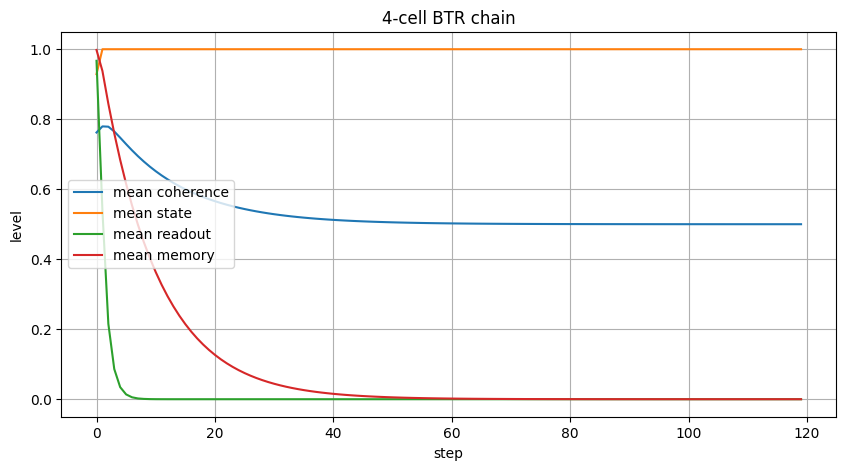

,step,input,final_emitted,mean_coherence,mean_state,mean_readout,mean_memory
115,115,0.280266,1.725437e-46,0.500024,1.0,2.323382e-46,0.000006
116,116,0.338663,6.901746e-47,0.500022,1.0,9.293529e-47,0.000005
117,117,0.403481,2.760699e-47,0.500020,1.0,3.717412e-47,0.000005
118,118,0.471419,1.104279e-47,0.500019,1.0,1.486965e-47,0.000004
119,119,0.538942,4.417118e-48,0.500017,1.0,5.947859e-48,0.000004


In [9]:

def run_chain(depth: int = 4, steps: int = 120, B: float = 1.0, T: float = 1.0, R: float = 1.0) -> pd.DataFrame:
    cells = [TriadicCellV2(B, T, R) for _ in range(depth)]
    states = [TriadicState() for _ in range(depth)]
    rows = []

    for i, x in enumerate(make_drive(steps)):
        signal = float(x)
        for j, cell in enumerate(cells):
            states[j], signal = cell.step(states[j], signal)

        rows.append({
            "step": i,
            "input": x,
            "final_emitted": signal,
            "mean_coherence": np.mean([s.coherence for s in states]),
            "mean_state": np.mean([s.state for s in states]),
            "mean_readout": np.mean([s.readout for s in states]),
            "mean_memory": np.mean([s.memory for s in states]),
        })

    return pd.DataFrame(rows)

chain_df = run_chain(depth=4, steps=120, B=1.0, T=1.0, R=1.0)

plt.figure(figsize=(10, 5))
plt.plot(chain_df["step"], chain_df["mean_coherence"], label="mean coherence")
plt.plot(chain_df["step"], chain_df["mean_state"], label="mean state")
plt.plot(chain_df["step"], chain_df["mean_readout"], label="mean readout")
plt.plot(chain_df["step"], chain_df["mean_memory"], label="mean memory")
plt.title("4-cell BTR chain")
plt.xlabel("step")
plt.ylabel("level")
plt.legend(loc="best")
plt.show()

chain_df.tail()



## Why this matters for AI

A plain model is usually strongest in:
- transformation
- readout

It is usually weakest in:
- explicit binding
- durable state retention
- memory of readable difference

This notebook is the first software move toward a different primitive:

not a token predictor first,
but a **triadic state machine** first.



## Next step after this notebook

If this version behaves the way it should, the next move is not more rhetoric.

It is:
1. make the state vector multidimensional
2. make readout selective instead of scalar
3. add an external persistent memory register
4. compare this against a plain transform/readout baseline
5. only then ask what model family should sit inside it
